In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress


In [2]:
base = Path.cwd().parent

raw = base / "data" / "raw"
processed = base / "data" / "processed"
charts = base / "reports" / "charts"

In [3]:
fund_master = pd.read_csv(
    raw / "01_fund_master.csv"
)

nav = pd.read_csv(
    processed / "nav_history_clean.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    raw / "10_benchmark_indices.csv",
    parse_dates=["date"]
)

In [4]:
print("Funds:", nav["amfi_code"].nunique())

print("\nBenchmark Names:")
print(
    benchmark["index_name"]
    .unique()
)

Funds: 40

Benchmark Names:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

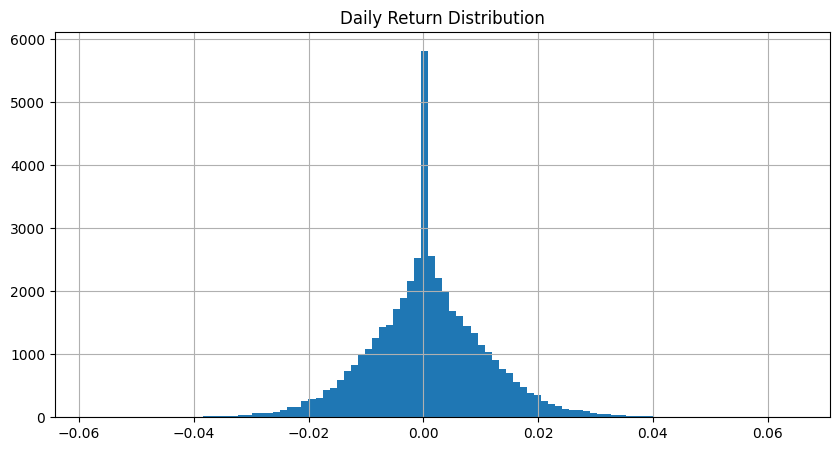

In [6]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [7]:
def calculate_cagr(df, years):

    results = []

    for code in df["amfi_code"].unique():

        fund = (
            df[df["amfi_code"] == code]
            .sort_values("date")
        )

        end_date = fund["date"].max()

        start_date = (
            end_date
            - pd.DateOffset(years=years)
        )

        fund_period = fund[
            fund["date"] >= start_date
        ]

        if len(fund_period) < 2:
            continue

        start_nav = (
            fund_period.iloc[0]["nav"]
        )

        end_nav = (
            fund_period.iloc[-1]["nav"]
        )

        cagr = (
            (end_nav / start_nav)
            ** (1 / years)
            - 1
        )

        results.append(
            [code, cagr]
        )

    return pd.DataFrame(
        results,
        columns=[
            "amfi_code",
            f"cagr_{years}yr"
        ]
    )

In [8]:
cagr_1 = calculate_cagr(nav, 1)

cagr_3 = calculate_cagr(nav, 3)

cagr_5 = calculate_cagr(nav, 5)

cagr_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [9]:
RF = 0.065

In [10]:
sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"] == code
        ]["daily_return"]
        .dropna()
    )

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_volatility

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"] == code
        ]["daily_return"]
        .dropna()
    )

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean() * 252
    )

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [12]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

In [13]:
nifty100_name = next(
    x
    for x in benchmark["index_name"].unique()
    if "100" in str(x)
)

nifty100 = benchmark[
    benchmark["index_name"]
    == nifty100_name
]

print(
    "Using benchmark:",
    nifty100_name
)

Using benchmark: NIFTY100


In [14]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ]

    merged = (
        fund.merge(
            nifty100[
                [
                    "date",
                    "benchmark_return"
                ]
            ],
            on="date"
        )
        .dropna()
    )

    if len(merged) < 30:
        continue

    slope, intercept, r, p, stderr = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()



,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
alpha_beta_df.to_csv(
    processed / "alpha_beta.csv",
    index=False
)

In [16]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[
            nav["amfi_code"] == code
        ]
        .sort_values("date")
        .copy()
    )

    fund["running_max"] = (
        fund["nav"]
        .cummax()
    )

    fund["drawdown"] = (
        fund["nav"]
        /
        fund["running_max"]
        - 1
    )

    max_dd = (
        fund["drawdown"]
        .min()
    )

    drawdown_results.append(
        [code, max_dd]
    )

dd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [17]:
scorecard = (
    cagr_table
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

In [18]:
scorecard = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

In [19]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [20]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["dd_rank"] * 10

)

In [21]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,84.5000
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,80.7500
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,80.5000
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,80.0000
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,78.2500
24,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,75.7500
21,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,75.1250
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,74.9375
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,73.9375
19,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,73.0625


In [22]:
scorecard.to_csv(
    processed / "fund_scorecard.csv",
    index=False
)

In [23]:
top5 = (
    scorecard
    .head(5)
)

top_codes = (
    top5["amfi_code"]
    .tolist()
)

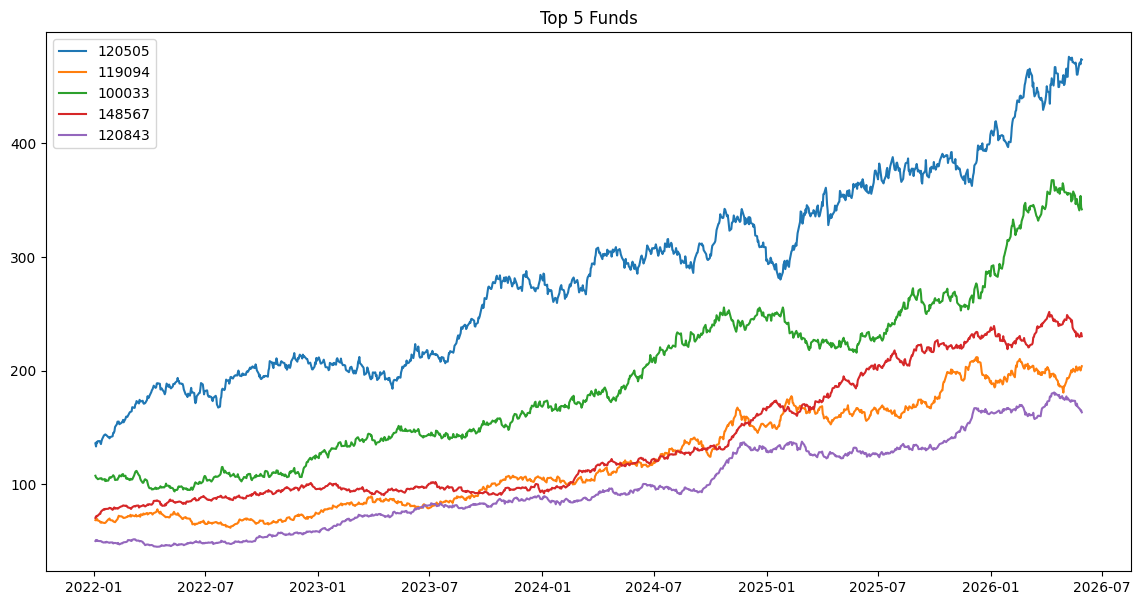

In [24]:
plt.figure(
    figsize=(14, 7)
)

for code in top_codes:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds"
)

plt.legend()

plt.savefig(
    charts
    / "benchmark_comparison.png"
)

plt.show()

In [25]:
annualised_returns = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[nav["amfi_code"] == code]
        .sort_values("date")
    )

    returns = fund["daily_return"].dropna()

    n = len(returns)

    if n == 0:
        continue

    annual_return = (
        (1 + returns).prod()
        ** (252 / n)
        - 1
    )

    annualised_returns.append(
        [code, annual_return]
    )

annualised_df = pd.DataFrame(
    annualised_returns,
    columns=[
        "amfi_code",
        "annualised_return"
    ]
)

annualised_df.to_csv(
    processed / "returns_computed.csv",
    index=False
)

annualised_df.head()

,amfi_code,annualised_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [26]:
cagr_table.to_csv(
    processed / "cagr_report.csv",
    index=False
)

In [27]:
sharpe_df.to_csv(
    processed / "sharpe_values.csv",
    index=False
)

In [28]:
sortino_df.to_csv(
    processed / "sortino_values.csv",
    index=False
)

In [29]:
dd_df.to_csv(
    processed / "max_drawdown.csv",
    index=False
)

In [30]:
drawdown_periods = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[nav["amfi_code"] == code]
        .sort_values("date")
        .copy()
    )

    fund["running_max"] = fund["nav"].cummax()

    fund["drawdown"] = (
        fund["nav"]
        / fund["running_max"]
        - 1
    )

    trough_idx = (
        fund["drawdown"]
        .idxmin()
    )

    trough_date = (
        fund.loc[
            trough_idx,
            "date"
        ]
    )

    peak_date = (
        fund.loc[
            :trough_idx,
            "nav"
        ]
        .idxmax()
    )

    peak_date = (
        fund.loc[
            peak_date,
            "date"
        ]
    )

    drawdown_periods.append(
        [
            code,
            peak_date,
            trough_date
        ]
    )

drawdown_period_df = pd.DataFrame(
    drawdown_periods,
    columns=[
        "amfi_code",
        "peak_date",
        "trough_date"
    ]
)

drawdown_period_df.head()

,amfi_code,peak_date,trough_date
0,100016,2022-03-30,2022-09-15
1,100025,2023-05-23,2023-07-28
2,100033,2022-03-11,2022-05-12
3,101206,2023-04-24,2023-07-05
4,101207,2024-11-21,2026-05-11


In [31]:
nifty50_name = next(
    x
    for x in benchmark["index_name"].unique()
    if "50" in str(x)
)

nifty100_name = next(
    x
    for x in benchmark["index_name"].unique()
    if "100" in str(x)
)

nifty50 = benchmark[
    benchmark["index_name"]
    == nifty50_name
]

nifty100 = benchmark[
    benchmark["index_name"]
    == nifty100_name
]

In [32]:
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

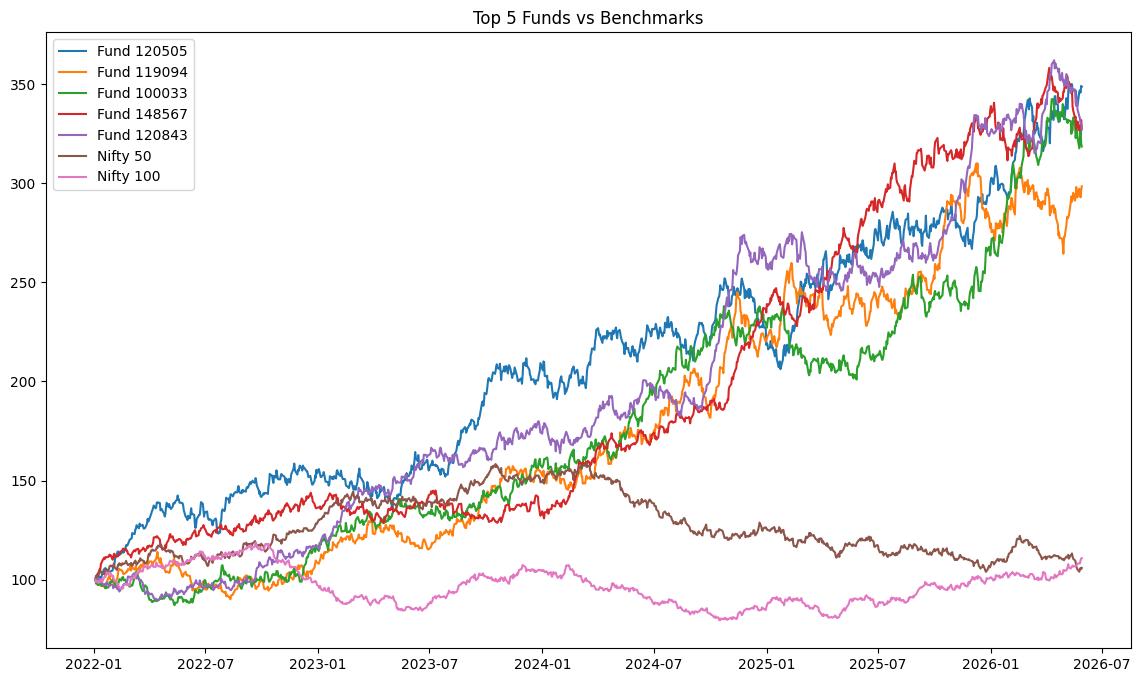

In [33]:
plt.figure(figsize=(14,8))

for code in top_codes:

    temp = (
        nav[
            nav["amfi_code"] == code
        ]
        .sort_values("date")
        .copy()
    )

    temp["normalized"] = (
        temp["nav"]
        / temp["nav"].iloc[0]
        * 100
    )

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="Nifty 50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    label="Nifty 100"
)

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.savefig(
    charts /
    "benchmark_comparison.png"
)

plt.show()

In [34]:
tracking_error = []

for code in top_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ]

    merged = (
        fund.merge(
            nifty100[
                [
                    "date",
                    "benchmark_return"
                ]
            ],
            on="date"
        )
        .dropna()
    )

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        )
        .std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,119094,0.237652
2,100033,0.228699
3,148567,0.189664
4,120843,0.206425


In [35]:
scorecard = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "category"
        ]
    ],
    on="amfi_code"
)

In [36]:
best_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .groupby("category")
    .head(1)
)

best_funds

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score,category
0,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36,0.9,0.90,0.95,0.65,0.625,84.50,Equity
27,120507,0.074251,0.073943,0.063417,0.495723,0.067462,-0.000444,-0.000977,0.74,0.3,0.45,0.25,0.85,0.025,38.25,Debt


In [37]:
worst_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=True
    )
    .groupby("category")
    .head(1)
)

worst_funds

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score,category
39,119092,0.016091,0.005259,0.055826,0.030785,0.068995,0.009731,-0.144016,1.64,0.125,0.25,0.275,0.0375,0.375,19.8125,Equity
36,100025,0.037050,0.039164,0.039127,-0.567095,0.042818,0.001158,-0.043083,0.56,0.175,0.05,0.075,0.9750,0.100,23.6250,Debt
